In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

In [2]:
η = 0.15

σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g
# Steers prox operators:
ρ_obj = 0.0

0.0

In [3]:
img = load("../reconstructions/1096.jpg")
img_f = img .|> Float64
img_f .-= 0.5
img_f .*= 2.0
img_f .= exp.(img_f) # Just an idea maybe EIT reconstruction is easier with this.

150×150 Matrix{Float64}:
 1.38471   1.39561   1.4066    1.4066    …  1.89499   1.88019   1.88019
 1.41768   1.42884   1.44009   1.44009      1.90992   1.90992   1.90992
 1.44009   1.45143   1.46286   1.46286      1.92495   1.92495   1.92495
 1.46286   1.47438   1.48599   1.48599      1.92495   1.92495   1.92495
 1.48599   1.49769   1.50948   1.50948      1.94011   1.94011   1.94011
 1.47438   1.48599   1.49769   1.49769   …  1.97078   1.97078   1.97078
 1.44009   1.45143   1.46286   1.46286      1.9863    1.9863    1.9863
 1.44009   1.45143   1.46286   1.46286      1.97078   1.9863    1.9863
 1.46286   1.46286   1.47438   1.48599      2.01771   2.00194   1.9863
 1.47438   1.48599   1.48599   1.49769      2.00194   2.00194   1.9863
 ⋮                                       ⋱                      
 0.367879  0.382593  0.388641  0.407368     0.388641  0.373696  0.388641
 0.394786  0.437162  0.385605  0.385605     0.394786  0.367879  0.373696
 0.385605  0.417066  0.42366   0.417066     0.39

In [4]:
itp = interpolate_array_2D(Float64.(img_f))

#interpolate_array_2D##0 (generic function with 1 method)

In [5]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));

In [6]:
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,1,0,3,∂Ω)

FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 1}(), [0.7872983346207417 0.44364916731037085 … 0.05635083268962915 0.012701665379258308; 0.09999999999999994 0.44364916731037085 … 0.05635083268962915 0.09999999999999999; 0.012701665379258296 0.05635083268962912 … 0.44364916731037085 0.7872983346207417; 0.09999999999999994 0.05635083268962912 … 0.44364916731037085 0.09999999999999999], [0.7872983346207417 0.44364916731037085 … 0.05635083268962915 0.012701665379258308; 0.099999999999999

In [7]:
cond_vec = project_function_to_fem(fe, itp; space=:σ)
cond_vec .= min.(max.(cond_vec, 1e-6), 2.8)

3969-element SparseArrays.SparseVector{Float64, Int64} with 3969 stored entries:
  [1   ]  =  1.43257
  [2   ]  =  1.4845
  [3   ]  =  1.46419
  [4   ]  =  1.47182
  [5   ]  =  1.49761
  [6   ]  =  1.5537
  [7   ]  =  1.59288
          ⋮
  [3962]  =  0.391354
  [3963]  =  0.405863
  [3964]  =  0.443788
  [3965]  =  0.403251
  [3966]  =  0.383249
  [3967]  =  0.386418
  [3968]  =  0.377171
  [3969]  =  0.382861

In [8]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [9]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:253
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i-1] = assemble_rhs_func(fe, itp)
end
G = zeros(fe.n,252)
for i in 1:252
    G[:,i] = rhs_dict[i]
end

In [10]:
fbm_true =  FerriteBlockMode(cond_vec, G, fe; block=false)

FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.25524077362757097 -0.06381019340689274 -0.12762038681378543 -0.06381019340689281; -0.06381019340689274 0.25524077362757147 -0.06381019340689284 -0.12762038681378587; -0.12762038681378543 -0.06381019340689284 0.2552407736275713 -0.063810193406893; -0.06381019340689281 -0.12762038681378587 -0.063810193406893 0.25524077362757164]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.9550479532649173, -0.2387619883162296, -0.4775239766324585, -0.23876198831622916, -0.2387619883162296, 1.944714705659659, -0.4861786764149203, -0.4775239766324585, -0.24741668809868, -0.49483337619737067  …  -0.12572368871325723, -0.12667203776352012, -0.12762038681378587, -0.06286184435662999, 0.5066881510540862

In [11]:
F = fbm_true.F
GS = copy(fe.down(fbm_true.G))
F, G , Σ = svd_on_modes(F,GS)

([-1.3651022150313705 -3.456669111863606 … -2.0608113459959135e-10 1.7431457145775017e-17; -1.3521818265658168 -3.4115576140546353 … -1.2507898387996713e-9 1.743145714449888e-17; … ; 12.287326815403825 5.707209341865827 … -1.2739122428633873e-9 1.7431457144688608e-17; 12.761754638758097 6.0004620125731725 … -3.7986208018143517e-10 1.7431457142658012e-17], [-0.019049704817560513 -0.061987732212115204 … 1.080340122402562e-9 0.06299407883487082; -0.018869402922880973 -0.061178752288851945 … -3.0669809623624438e-9 0.06299407883487361; … ; 0.1714669842633846 0.10234619630494314 … -4.301937834267596e-9 0.06299407883487049; 0.1780875097952142 0.10760504189069646 … -9.045881928362039e-10 0.06299407883487111], [71.66001807188646, 55.7637635276769, 31.55122007181819, 22.524672020918533, 20.01444471864472, 16.438409511489798, 15.1149509579078, 14.480175469876144, 11.362457224656245, 9.817115500100678  …  0.28153898627041724, 0.2791846744011368, 0.275400290049903, 0.2685883985130166, 0.26736575619

In [12]:
fbm = FerriteBlockMode(F, fe.up(G), fe)

FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 4096, 4096), sparse([1, 2, 3, 4, 4097, 1, 2, 3, 4, 5  …  4087, 4088, 4089, 4090, 4091, 4092, 4093, 4094, 4095, 4096], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  4097, 4097, 4097, 4097, 4097, 4097, 4097, 4097, 4097, 4097], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 4097, 4097), [-1.3651022150313705 -3.456669111863606 … -2.0608113459959135e-10 1.7431457145775017e-17; -1.3521818265658168 -3.4115576140546353 … -1.250789838

In [34]:
f, ∂f =  create_block_f∂f(fbm, fe;
                           nmodes=100, block=true,
                           gn=true, λ=1e-2)

(ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}(100, true, 1.0, nothing, 0.0, FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.4512755961107602 -0.11281889902769003 -0.22563779805538 -0.11281889902769018; -0.11281889902769003 0.451275596110761 -0.11281889902769024 -0.22563779805538078; -0.22563779805538 -0.11281889902769024 0.4512755961107608 -0.11281889902769052; -0.11281889902769018 -0.22563779805538078 -0.11281889902769052 0.4512755961107614]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.8847111441654227, -0.22117778604135593, -0.44235557208271126, -0.2211777860413555

In [35]:
#prox_obj = create_proximal_gradient_step(f,∂f,ρ_obj, fe.n_σ)
prox_obj = create_prox_linesearch(f,∂f,ρ_obj)

(::ModularEIT.var"#prox#90"{Float64, ModularEIT.var"#prox#87#91"{ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}, ModularEIT.var"#57#58"{Int64, Bool, Float64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}, Base.RefValue{Bool}, Base.RefValue{Union{Nothing, Vector{Float64}}}, Base.RefValue{Union{Nothing, Vector{Float64}}}}}, Bool, Nothing, Float64, Float64, Int64}) (generic function with 2 methods)

In [36]:
fbm

FerriteBlockMode(ModularEIT.BlockLAssembler(4, [0.4512755961107602 -0.11281889902769003 -0.22563779805538 -0.11281889902769018; -0.11281889902769003 0.451275596110761 -0.11281889902769024 -0.22563779805538078; -0.22563779805538 -0.11281889902769024 0.4512755961107608 -0.11281889902769052; -0.11281889902769018 -0.22563779805538078 -0.11281889902769052 0.4512755961107614]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], sparse([1, 2, 3, 4, 1, 2, 3, 4, 5, 6  …  4030, 4031, 4032, 4094, 4095, 4096, 4031, 4032, 4095, 4096], [1, 1, 1, 1, 2, 2, 2, 2, 2, 2  …  4095, 4095, 4095, 4095, 4095, 4095, 4096, 4096, 4096, 4096], [0.8847111441654227, -0.22117778604135593, -0.44235557208271126, -0.22117778604135557, -0.22117778604135593, 1.716873305830775, -0.4292183264576984, -0.44235557208271126, -0.2080405404163335, -0.4160810808326761  …  -0.33609470936018565, -0.2808662537077795, -0.22563779805538078, -0.1680473546800965, 1.1234650148311327, -

In [37]:
σ₁ = ones(fe.n_σ)


3969-element Vector{Float64}:
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0

In [38]:
σᵢ, err, _ = prox_obj(σ₁) 

linesearch  iter=0  err=31.585554347576984
linesearch  iter=1  τ=0.4616147723518794  err=14.870514494548722
linesearch  iter=2  τ=0.34021124587682644  err=9.900092804312422
linesearch  iter=3  τ=0.22735686893462412  err=7.735851082186453
linesearch  iter=4  τ=1.0587382304640988e-8  err=7.7358508680967475
linesearch  iter=5  no improvement (err=7.735850869744803 ≥ 7.7358508680967475 - tol), stopping


([1.1975165198219904, 1.1229387119819536, 1.1129670793060085, 1.1310795938057625, 1.1616605941046385, 1.1949806865469979, 1.2260245550046744, 1.2522673289813184, 1.272348630063657, 1.2858727843930697  …  0.1178958206085431, 0.34030846760076794, 0.31057007869785286, 0.2850121590975881, 0.3060768909194786, 0.696940900729406, 0.4223381966830564, 0.6556406724278192, 0.5546853539785739, 0.5587154402082292], 7.7358508680967475, 0.0)

In [39]:
# Choose some starting sigma:

In [40]:
σ_img = log.(reshape(evaluate_at_points(ph, fe.dh_σ, σᵢ), (64, 64)))

64×64 Matrix{Float64}:
  0.18025    0.18025    0.181636   …   0.155881   0.162355   0.174008
  0.18025    0.18025    0.181636       0.155881   0.162355   0.174008
  0.115949   0.115949   0.133607       0.133973   0.14399    0.150097
  0.107029   0.107029   0.119568       0.133358   0.145436   0.15657
  0.123173   0.123173   0.130954       0.146861   0.161358   0.175314
  0.149851   0.149851   0.153424   …   0.167586   0.183219   0.198326
  0.17813    0.17813    0.17849        0.190431   0.206035   0.220857
  0.203777   0.203777   0.201551       0.212453   0.227148   0.240798
  0.224956   0.224956   0.220411       0.232149   0.245381   0.257272
  0.240865   0.240865   0.23424        0.248878   0.260337   0.270193
  ⋮                                ⋱                        
 -1.67172   -1.67172   -0.413015   …  -0.347686  -1.11674   -1.0779
 -1.20988   -1.20988   -0.253969      -0.444325  -1.02243   -1.16935
 -1.01882   -1.01882   -0.134278      -0.413101  -0.744854  -1.25522
 -1.38318  

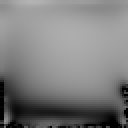

In [41]:
σ_img = Gray.(((σ_img) .*0.5) .+0.5)

In [42]:
#save("linesearch_unregularized.png", map(clamp01nan, σ_img))

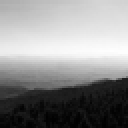

In [43]:
# cond_vec lives on the σ-space (fe.dh_σ), not the u-space (fe.dh) — must
# evaluate against fe.dh_σ to read the conductivity image back out.
cond_img = reshape(evaluate_at_points(ph, fe.dh_σ, cond_vec), (64, 64))
cond_img = Gray.(log.(cond_img) .*0.5 .+0.5)